# 02 — Battery Data Validation

**Goal of this notebook:** validate the NASA PCoE battery data pipeline _before_ any modelling.
We load one `.mat` file, inspect its nested structure, extract discharge cycles, compute SOH,
plot capacity fade, and confirm that the two operational thresholds can be detected cleanly.

**Data source:** NASA Ames Prognostics Center of Excellence (PCoE)  
https://www.nasa.gov/content/prognostics-center-of-excellence-data-set-repository  
Cells: B0005, B0006, B0007, B0018 — 2 Ah nominal, cycled at 24 °C.

**Threshold convention used in this project:**
| Threshold | SOH | Capacity | Meaning |
|-----------|-----|----------|---------|
| Operational warning | 80 % | 1.60 Ah | Flag vehicle for inspection |
| End of life (NASA) | 70 % | ~1.40 Ah | Ground the vehicle |

---
**Steps:**
1. Download data  
2. Load one `.mat` file  
3. Inspect the nested structure  
4. Extract discharge cycles  
5. Compute SOH  
6. Plot capacity fade with threshold lines  
7. Report threshold crossings  

## 0 — Download instructions

Download the four battery files and place them in `data/raw/`:

```bash
cd data/raw

# Option A — direct wget (if the NASA server allows it)
wget https://ti.arc.nasa.gov/c/6/  -O B0005.mat

# Option B — manual download (recommended)
# Go to: https://www.nasa.gov/content/prognostics-center-of-excellence-data-set-repository
# Find: "Battery Data Set" → download the ZIP → extract B0005.mat … B0018.mat
# Place them in: polaris-fleet-energy-risk/data/raw/
```

We will work with **B0005.mat** in this notebook.

## 1 — Imports

In [2]:
import sys
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path('../src').resolve()))

from battery_features import (
    load_battery_mat,
    extract_discharge_cycles,
    compute_soh,
    find_threshold_crossing,
    summarise_degradation,
    NOMINAL_CAPACITY_AH,
    SOH_WARNING_THRESHOLD,
    SOH_EOL_THRESHOLD,
)

# Paths
DATA_RAW = Path('../data/raw')
FIGURES  = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

BATTERY_FILE = DATA_RAW / 'B0005.mat'

print('Python path ok:', sys.path[0])
print('Battery file exists:', BATTERY_FILE.exists())


Python path ok: /Users/arthurbarbarin/Polaris_sprint/Polaris/src
Battery file exists: True


## 2 — Load the .mat file and inspect the raw structure

The NASA `.mat` files use MATLAB structs nested several levels deep.  
`scipy.io.loadmat(..., simplify_cells=True)` flattens them into ordinary Python
dicts and lists, which is much easier to work with.

In [3]:
# ── Raw load (for inspection) ────────────────────────────────────────────────
mat_raw = sio.loadmat(str(BATTERY_FILE), simplify_cells=True)

print('Top-level keys in .mat file:')
for k in mat_raw.keys():
    print(f'  {k!r:25s}  type={type(mat_raw[k]).__name__}')

# The battery variable is the one that doesn't start with '_'
battery_key = [k for k in mat_raw if not k.startswith('_')][0]
battery = mat_raw[battery_key]
print(f'\nBattery key: {battery_key!r}')
print(f'Battery dict keys: {list(battery.keys())}')

Top-level keys in .mat file:
  '__header__'               type=bytes
  '__version__'              type=str
  '__globals__'              type=list
  'B0005'                    type=dict

Battery key: 'B0005'
Battery dict keys: ['cycle']


In [4]:
# ── Inspect the cycle list ────────────────────────────────────────────────────
cycles = battery['cycle']
print(f'Total cycles in file: {len(cycles)}')

# Count cycle types
from collections import Counter
type_counts = Counter(c['type'].strip() for c in cycles)
print('\nCycle type counts:')
for ctype, count in sorted(type_counts.items()):
    print(f'  {ctype:12s}: {count}')

Total cycles in file: 616

Cycle type counts:
  charge      : 170
  discharge   : 168
  impedance   : 278


In [5]:
# ── Inspect one discharge cycle in detail ─────────────────────────────────────
first_discharge = next(c for c in cycles if c['type'].strip() == 'discharge')

print('Keys in a discharge cycle dict:')
for k, v in first_discharge.items():
    print(f'  {k:22s}  type={type(v).__name__}')

print('\nKeys in cycle["data"]:')
for k, v in first_discharge['data'].items():
    val_preview = v if np.isscalar(v) else f'array shape={np.array(v).shape}'
    print(f'  {k:30s}  {val_preview}')

Keys in a discharge cycle dict:
  type                    type=str
  ambient_temperature     type=int
  time                    type=ndarray
  data                    type=dict

Keys in cycle["data"]:
  Voltage_measured                array shape=(197,)
  Current_measured                array shape=(197,)
  Temperature_measured            array shape=(197,)
  Current_load                    array shape=(197,)
  Voltage_load                    array shape=(197,)
  Time                            array shape=(197,)
  Capacity                        1.8564874208181574


### What we expect to see

The `data` dict of a discharge cycle should contain time-series arrays for
`Voltage_measured`, `Current_measured`, `Temperature_measured`, `Time`, and  
a scalar (or 1-element array) `Capacity` — the total Ah delivered during that cycle.

We only need `Capacity` (and optionally `Temperature_measured`) for this validation step.

## 3 — Extract discharge cycles

In [6]:
# Use the clean function from src/battery_features.py
battery_loaded = load_battery_mat(BATTERY_FILE)
discharge_records = extract_discharge_cycles(battery_loaded)

print(f'Discharge cycles found: {len(discharge_records)}')
print('\nFirst 5 records:')
for r in discharge_records[:5]:
    print(f'  {r}')
print('\nLast 5 records:')
for r in discharge_records[-5:]:
    print(f'  {r}')

  Loaded 'B0005' from B0005.mat
Discharge cycles found: 168

First 5 records:
  {'cycle_index': 2, 'discharge_num': 1, 'capacity': 1.8564874208181574, 'ambient_temp': 24.0}
  {'cycle_index': 4, 'discharge_num': 2, 'capacity': 1.846327249719927, 'ambient_temp': 24.0}
  {'cycle_index': 6, 'discharge_num': 3, 'capacity': 1.8353491942234077, 'ambient_temp': 24.0}
  {'cycle_index': 8, 'discharge_num': 4, 'capacity': 1.8352625275821128, 'ambient_temp': 24.0}
  {'cycle_index': 10, 'discharge_num': 5, 'capacity': 1.8346455082120419, 'ambient_temp': 24.0}

Last 5 records:
  {'cycle_index': 600, 'discharge_num': 164, 'capacity': 1.293463613844243, 'ambient_temp': 24.0}
  {'cycle_index': 604, 'discharge_num': 165, 'capacity': 1.288003392619118, 'ambient_temp': 24.0}
  {'cycle_index': 608, 'discharge_num': 166, 'capacity': 1.2874525221379407, 'ambient_temp': 24.0}
  {'cycle_index': 612, 'discharge_num': 167, 'capacity': 1.3090153642307354, 'ambient_temp': 24.0}
  {'cycle_index': 614, 'discharge_nu

## 4 — Compute SOH

SOH is defined relative to the capacity measured on the **first discharge cycle** —
not the nominal 2 Ah — because that is the baseline the model actually observed.
The nominal value is a datasheet spec; the measured first-cycle value is the real starting point.

In [7]:
discharge_records = compute_soh(discharge_records)

discharge_nums = [r['discharge_num'] for r in discharge_records]
capacities     = [r['capacity']      for r in discharge_records]
soh_values     = [r['soh']           for r in discharge_records]

print(f'Initial capacity (cycle 1): {capacities[0]:.4f} Ah')
print(f'Final  capacity (last cycle): {capacities[-1]:.4f} Ah')
print(f'Final  SOH: {soh_values[-1]:.3f} ({soh_values[-1]*100:.1f} %)')

  Initial capacity set from first discharge cycle: 1.8565 Ah
Initial capacity (cycle 1): 1.8565 Ah
Final  capacity (last cycle): 1.3251 Ah
Final  SOH: 0.714 (71.4 %)


## 5 — Detect threshold crossings

In [8]:
summary = summarise_degradation(discharge_records)

warning_cycle = summary['warning_cycle']
eol_cycle     = summary['eol_cycle']

print('=== Degradation Summary ===')
for k, v in summary.items():
    print(f'  {k:30s}: {v}')

print()
if warning_cycle:
    print(f'⚠  SOH crossed 80 % (operational warning) at discharge cycle {warning_cycle}')
else:
    print('ℹ  SOH never crossed 80 % warning threshold in this dataset')

if eol_cycle:
    print(f'🔴 SOH crossed 70 % (end of life) at discharge cycle {eol_cycle}')
else:
    print('ℹ  SOH never crossed 70 % EOL threshold in this dataset')

=== Degradation Summary ===
  total_discharge_cycles        : 168
  initial_capacity_ah           : 1.8564874208181574
  final_capacity_ah             : 1.3250793286429356
  final_soh                     : 0.7137561578838874
  warning_cycle                 : 101
  eol_cycle                     : 162
  crossed_eol                   : True

⚠  SOH crossed 80 % (operational warning) at discharge cycle 101
🔴 SOH crossed 70 % (end of life) at discharge cycle 162


## 6 — Plot: capacity fade over cycles

Figure saved → ../outputs/figures/B0005_capacity_fade.png


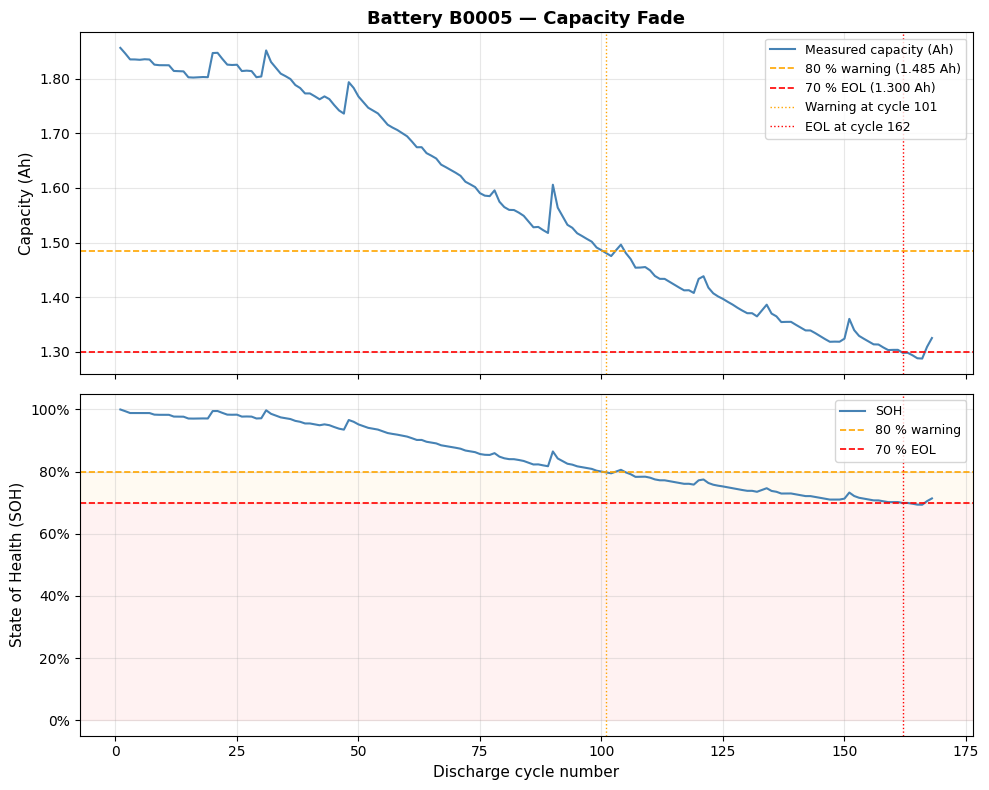

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# ── Top panel: raw capacity ───────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(discharge_nums, capacities, color='steelblue', linewidth=1.5,
         label='Measured capacity (Ah)')

# Threshold lines
cap_warning = SOH_WARNING_THRESHOLD * capacities[0]
cap_eol     = SOH_EOL_THRESHOLD     * capacities[0]
ax1.axhline(cap_warning, color='orange', linestyle='--', linewidth=1.2,
            label=f'80 % warning ({cap_warning:.3f} Ah)')
ax1.axhline(cap_eol, color='red', linestyle='--', linewidth=1.2,
            label=f'70 % EOL ({cap_eol:.3f} Ah)')

# Mark crossing points
if warning_cycle:
    ax1.axvline(warning_cycle, color='orange', linestyle=':', linewidth=1,
                label=f'Warning at cycle {warning_cycle}')
if eol_cycle:
    ax1.axvline(eol_cycle, color='red', linestyle=':', linewidth=1,
                label=f'EOL at cycle {eol_cycle}')

ax1.set_ylabel('Capacity (Ah)', fontsize=11)
ax1.set_title(f'Battery B0005 — Capacity Fade', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# ── Bottom panel: SOH ─────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(discharge_nums, soh_values, color='steelblue', linewidth=1.5,
         label='SOH')
ax2.axhline(SOH_WARNING_THRESHOLD, color='orange', linestyle='--', linewidth=1.2,
            label=f'80 % warning')
ax2.axhline(SOH_EOL_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
            label=f'70 % EOL')

# Shade regions
ax2.axhspan(SOH_EOL_THRESHOLD, SOH_WARNING_THRESHOLD, alpha=0.05, color='orange')
ax2.axhspan(0, SOH_EOL_THRESHOLD, alpha=0.05, color='red')

if warning_cycle:
    ax2.axvline(warning_cycle, color='orange', linestyle=':', linewidth=1)
if eol_cycle:
    ax2.axvline(eol_cycle, color='red', linestyle=':', linewidth=1)

ax2.set_xlabel('Discharge cycle number', fontsize=11)
ax2.set_ylabel('State of Health (SOH)', fontsize=11)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES / 'B0005_capacity_fade.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figure saved → {fig_path}')
plt.show()

## 7 — Sanity checks before continuing

Before moving to modelling, confirm:

| Check | Expected | Your result |
|-------|----------|-------------|
| Total discharge cycles | ~168 for B0005 | ← fill in |
| Initial capacity | 1.85 – 2.00 Ah | ← fill in |
| Final capacity | < 1.4 Ah (if EOL reached) | ← fill in |
| SOH plot shape | Smooth monotonic decay | ← check plot |
| 80 % crossing detected | Yes (~cycle 100–120 for B0005) | ← fill in |
| 70 % crossing detected | Yes (~cycle 150–168 for B0005) | ← fill in |

If the SOH curve looks noisy or the crossing cycles seem off, go back to  
`extract_discharge_cycles()` and inspect the raw `Capacity` field shape more carefully.

In [10]:
# Quick numeric sanity check — prints a pass/fail for each condition
checks = {
    'At least 100 discharge cycles': len(discharge_records) >= 100,
    'Initial capacity in [1.7, 2.1] Ah': 1.7 <= capacities[0] <= 2.1,
    'SOH is monotonically non-increasing (broadly)': soh_values[-1] < soh_values[0],
    'No NaN capacities': not any(np.isnan(c) for c in capacities),
    '80 % warning crossing detected': summary['crossed_warning'],
}

all_passed = True
for desc, passed in checks.items():
    icon = '✅' if passed else '❌'
    print(f'{icon}  {desc}')
    if not passed:
        all_passed = False

print()
if all_passed:
    print('All checks passed — pipeline is ready for feature extraction.')
else:
    print('Some checks failed — inspect the raw structure above before continuing.')

✅  At least 100 discharge cycles
✅  Initial capacity in [1.7, 2.1] Ah
✅  SOH is monotonically non-increasing (broadly)
✅  No NaN capacities
✅  80 % warning crossing detected

All checks passed — pipeline is ready for feature extraction.


In [11]:
import sys
!{sys.executable} -m pip install numpy scipy matplotlib pandas scikit-learn jupyter ipykernel


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [12]:
import numpy as np

import scipy.io as sio

import matplotlib.pyplot as plt

print("Imports work")

Imports work


---
## 8 — Full feature extraction

We now go beyond raw capacity and extract features from the **time-series** recorded
inside each discharge cycle (voltage, temperature, time arrays).

Each feature is physically motivated:

| Feature | Why it matters |
|---------|---------------|
| `mean_discharge_voltage` | Aging increases internal resistance → voltage under load drops |
| `min_discharge_voltage` | The lowest voltage reached — sensitive to end-of-discharge behaviour |
| `mean_temperature` / `max_temperature` | Heat accelerates degradation; hotter cycles = faster fade |
| `discharge_duration` | An aged cell empties faster (less stored energy) |
| `capacity_fade_rate` | Local slope of degradation — how fast capacity is dropping right now |
| `soh` | The primary regression target |

In [ ]:
from battery_features import extract_cycle_features, add_rul_targets, build_dataset
import pandas as pd

# Extract full features for B0005 first
battery_b5 = load_battery_mat(BATTERY_FILE)
df_b5 = extract_cycle_features(battery_b5)
df_b5 = add_rul_targets(df_b5)
df_b5.insert(0, 'battery_id', 'B0005')

print(f'Shape: {df_b5.shape}')
print(f'\nColumns: {list(df_b5.columns)}')
df_b5.head(8)

In [ ]:
# Quick check: any NaNs in features?
nan_counts = df_b5.isna().sum()
print('NaN counts per column:')
print(nan_counts[nan_counts > 0] if nan_counts.any() else '  None — all features complete.')

## 9 — Build the full multi-battery dataset

We process all four batteries and stack them into one DataFrame.
The `battery_id` column lets us treat each cell as a separate unit during
cross-validation.

> **Important:** when we validate models later, we will hold out entire batteries
> (e.g. train on B0005/B0006/B0007, test on B0018), not random cycles.
> Mixing cycles from the same battery across train/test would leak the degradation
> trajectory and inflate performance metrics.

In [ ]:
BATTERY_FILES = ['B0005.mat', 'B0006.mat', 'B0007.mat', 'B0018.mat']

df_all = build_dataset(BATTERY_FILES, data_dir=DATA_RAW)

print('\nPer-battery cycle counts:')
print(df_all.groupby('battery_id')['discharge_num'].max())

print('\nDataset summary:')
df_all.describe().round(3)

## 10 — Feature correlation & EDA plots

In [ ]:
FEATURE_COLS = [
    'discharge_num', 'mean_discharge_voltage', 'min_discharge_voltage',
    'mean_temperature', 'max_temperature', 'discharge_duration',
    'capacity_fade_rate',
]
TARGET = 'soh'

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

colors = {'B0005': 'steelblue', 'B0006': 'darkorange',
          'B0007': 'seagreen',  'B0018': 'crimson'}

for ax, feature in zip(axes, FEATURE_COLS):
    for battery_id, group in df_all.groupby('battery_id'):
        ax.scatter(group[feature], group[TARGET],
                   s=4, alpha=0.5, color=colors[battery_id], label=battery_id)
    ax.set_xlabel(feature, fontsize=8)
    ax.set_ylabel('SOH', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=9, title='Battery', ncol=2)

for ax in axes[len(FEATURE_COLS):]:
    ax.set_visible(False)

fig.suptitle('Feature vs SOH — all batteries', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 1])

fig_path = FIGURES / 'feature_vs_soh.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Figure saved -> {fig_path}')
plt.show()

In [ ]:
# Pearson correlation of each feature with SOH
corr = df_all[FEATURE_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
print('Correlation with SOH (Pearson):')
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['tomato' if c < 0 else 'steelblue' for c in corr]
corr.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with SOH', fontsize=10)
ax.set_title('Feature correlation with SOH', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig_path = FIGURES / 'feature_correlation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'\nFigure saved -> {fig_path}')
plt.show()

## 11 — Save processed dataset

In [ ]:
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / 'battery_features.csv'
df_all.to_csv(output_path, index=False)

print(f'Dataset saved -> {output_path}')
print(f'Shape: {df_all.shape}')
print(f'Columns: {list(df_all.columns)}')

## 12 — What to check before continuing to modelling

| Check | What to look for |
|-------|------------------|
| Feature scatter plots (section 10) | Clear trend with SOH — especially `discharge_num`, `mean_discharge_voltage`, `discharge_duration` |
| Correlation bar chart | `discharge_num` and `discharge_duration` should have the highest absolute correlation |
| NaN check | All four batteries should show zero NaNs in feature columns |
| Per-battery cycle counts | B0005/B0006/B0007 ~168 cycles; B0018 shorter (~132) — expected |
| `rul_warning` / `rul_eol` | Should count down to 0 then stay at 0, not jump around |

If all clean, `data/processed/battery_features.csv` is the input for notebook `04_model_training.ipynb`.